# 汽车零部件采购订单价格分析与异常检测
## 项目类型
这是一个类型一项目：使用Python对业务数据集进行分析。项目旨在通过分析公开订单数据，模拟汽车零部件采购场景，构建价格预测与异常检测模型，辅助财务分析师进行成本监控和采购审核。是一个价格分析 + 异常检测 + 决策支持的综合型项目

## 项目背景：财务分析师的真实困境
在汽车制造企业中，零部件采购成本直接影响整车利润。作为一名财务分析师，每月面对数千条采购订单记录，需要回答几个核心问题：
- 这个月的采购成本正常吗？
- 哪些订单的价格“值得多看一眼”？
- 不同供应商的价格水平差异有多大？
- 预算偏差到底是市场波动，还是执行问题？

目前的做法通常是：在Excel里做透视表，计算平均值，然后凭经验判断。这种方式存在三个问题：
- 信息过载：几千条订单，只能看大额或随机抽查，容易遗漏异常
- 标准不一致：凭经验判断，不同人标准不同，难以形成共识
- 无法量化：领导问“为什么觉得这个价格高？”，只能说“感觉”，拿不出数据支撑

## 项目目标
本项目的目标是构建一套采购价格合理性评估体系，实现以下功能：
- 分析价格分布特征，识别长尾现象: 理解整体价格结构，避免被平均值误导
- 对比不同类目、不同卖家的价格水平: 发现系统性的价格差异
- 用统计方法标记异常高价/低价订单: 从几千条订单中聚焦几十条可疑订单
- 建立回归模型，量化价格影响因素: 解释“为什么这个价格高/低”
- 构建随机森林预测模型: 为未来采购提供价格基准参考

## 项目声明
- 数据来源于 Olist 巴西电商公开数据集中的订单明细 （https://github.com/olist/work-at-olist-data/tree/master/datasets）
- 这个项目的核心不是“预测未来价格”，而是“基于历史数据，学习什么是正常的价格”
- Used python 3.8.10

In [3]:
# Several libraries are required for this project. You can install them using pip:

# pathlib is a standard library for working with file paths, which provides an object-oriented interface for handling filesystem paths.
# numpy is a fundamental package for scientific computing in Python, which provides support for arrays, matrices
# matplotlib is a plotting library for creating static, animated, and interactive visualizations in Python.
# seaborn is a data visualization library based on matplotlib, which provides a high-level interface for drawing attractive and informative statistical graphics.
# statsmodels is a library for estimating and testing statistical models, which provides classes and functions for the estimation of many different statistical models, as well as for conducting statistical tests and statistical data exploration.
# scikit-learn is a machine learning library that provides simple and efficient tools for data mining and data analysis, built on top of NumPy, SciPy, and matplotlib.

%pip install pathlib numpy matplotlib seaborn statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# 0. 环境准备
import os
import pathlib # 文件路径处理:
import numpy as np # 数值计算: 数组、矩阵等, 提供了大量的数学函数ß
import pandas as pd # 数据处理: 提供了DataFrame数据结构, 方便数据清洗、分析和可视化
import matplotlib.pyplot as plt # 数据可视化: 提供了丰富的绘图功能, 可以创建各种类型的图表
import seaborn as sns # 数据可视化: 基于matplotlib的高级接口, 提供了更美观和易用的绘图功能

from datetime import datetime

import statsmodels.api as sm # 统计建模: 提供了丰富的统计模型和方法, 包括线性回归、时间序列分析等
import statsmodels.formula.api as smf # 统计建模: 提供了基于公式的接口, 方便进行统计建模和分析

from sklearn.model_selection import train_test_split # 数据划分: 将数据集划分为训练集和测试集, 以评估模型性能
from sklearn.compose import ColumnTransformer # 数据预处理: 用于对不同类型的特征进行不同的预处理操作
from sklearn.preprocessing import OneHotEncoder, StandardScaler # 数据预处理: OneHotEncoder用于对分类特征进行独热编码, StandardScaler用于对数值特征进行标准化
from sklearn.pipeline import Pipeline # 数据处理管道: 用于将多个数据处理步骤组合成一个整体, 方便进行数据预处理和模型训练
from sklearn.ensemble import RandomForestRegressor # 机器学习模型: 随机森林回归模型, 用于进行回归任务
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # 模型评估: 用于评估回归模型的性能, 包括平均绝对误差、均方误差和R²分数等指标

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 200)

print('Today:', datetime.now().strftime('%Y-%m-%d'))

Today: 2026-03-23


## 1. 研究问题（Questions of Interest）

围绕“订单明细价格”与“到手成本（含运费）”，关注：

1. 汽车零部件类目下，`price` 的分布特征如何？是否长尾？中位数/分位数是多少？
2. 不同子类目（category）之间价格差异是否显著？
3. 不同卖家（seller）之间的价格水平差异有多大？
4. 异常检测：哪些订单明细属于明显异常高价/低价？它们来自哪些类目/卖家？
5. 能否用回归模型解释价格（例如 log(price)）与运费、时间、类目等变量的关系？

## 2. 数据获取与合并（Download & Join）

本项目只选取Olist巴西电商公开数据集中和价格成本相关的五类数据，由于在公开数据中为单独保存，在分析中需要将他们关照关联关系合并

In [5]:
# 2.1 下载数据（如本地不存在）
import urllib.request

raw_dir = pathlib.Path('data_raw')
raw_dir.mkdir(parents=True, exist_ok=True)

base = 'https://raw.githubusercontent.com/olist/work-at-olist-data/master/datasets/'
files = {
    'order_items': 'olist_order_items_dataset.csv',
    'orders':      'olist_orders_dataset.csv',
    'products':    'olist_products_dataset.csv',
    'category':    'product_category_name_translation.csv',
    'sellers':     'olist_sellers_dataset.csv'
}

for key, fname in files.items():
    path = raw_dir / fname
    if not path.exists():
        url = base + fname
        print('Downloading:', url)
        urllib.request.urlretrieve(url, path)

# 2.2 读取
order_items = pd.read_csv(raw_dir / files['order_items'])
orders      = pd.read_csv(raw_dir / files['orders'])
products    = pd.read_csv(raw_dir / files['products'])
cat_trans   = pd.read_csv(raw_dir / files['category'])
sellers     = pd.read_csv(raw_dir / files['sellers'])

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
# 2.3 合并为“订单明细分析表”
cat_trans2 = cat_trans.rename(columns={
    'product_category_name': 'product_category_name',
    'product_category_name_english': 'category_en'
})

items_full = (order_items
    .merge(orders[['order_id','order_purchase_timestamp','order_approved_at','order_status']],
           on='order_id', how='left')
    .merge(products[['product_id','product_category_name','product_weight_g','product_length_cm',
                    'product_height_cm','product_width_cm']],
           on='product_id', how='left')
    .merge(cat_trans2[['product_category_name','category_en']],
           on='product_category_name', how='left')
    .merge(sellers[['seller_id','seller_state']],
           on='seller_id', how='left')
)

items_full.shape, items_full.columns.tolist()[:15]

((112650, 17),
 ['order_id',
  'order_item_id',
  'product_id',
  'seller_id',
  'shipping_limit_date',
  'price',
  'freight_value',
  'order_purchase_timestamp',
  'order_approved_at',
  'order_status',
  'product_category_name',
  'product_weight_g',
  'product_length_cm',
  'product_height_cm',
  'product_width_cm'])

查看合并后的数据结构

In [7]:
items_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  112650 non-null  object 
 1   order_item_id             112650 non-null  int64  
 2   product_id                112650 non-null  object 
 3   seller_id                 112650 non-null  object 
 4   shipping_limit_date       112650 non-null  object 
 5   price                     112650 non-null  float64
 6   freight_value             112650 non-null  float64
 7   order_purchase_timestamp  112650 non-null  object 
 8   order_approved_at         112635 non-null  object 
 9   order_status              112650 non-null  object 
 10  product_category_name     111047 non-null  object 
 11  product_weight_g          112632 non-null  float64
 12  product_length_cm         112632 non-null  float64
 13  product_height_cm         112632 non-null  f

考虑到这是Olist电商的所有数据，查看下一共包含哪些类别

In [9]:
items_full['category_en'].value_counts(dropna=False)

category_en
bed_bath_table               11115
health_beauty                 9670
sports_leisure                8641
furniture_decor               8334
computers_accessories         7827
                             ...  
arts_and_craftmanship           24
cds_dvds_musicals               14
la_cuisine                      14
fashion_childrens_clothes        8
security_and_services            2
Name: count, Length: 72, dtype: int64

## 3. 过滤“汽车零部件”相关类目

该数据集为Olist 巴西电商公开数据集，包含了Olist所有类别的数据。在本次项目中，只过滤出汽车相关数据，使用英文翻译后的 `category_en` 做关键词过滤（auto/automotive/car）。

In [12]:
items_full['purchase_time'] = pd.to_datetime(items_full['order_purchase_timestamp'], errors='coerce')
items_full['approved_time'] = pd.to_datetime(items_full['order_approved_at'], errors='coerce')

mask_auto = (items_full['category_en'].notna() &
             items_full['category_en'].str.lower().str.contains('auto|automotive|car', regex=True))
items_auto = items_full.loc[mask_auto].copy()

(items_auto['category_en']
 .value_counts()
 .head(20))

category_en
auto    4235
Name: count, dtype: int64

查看和价格相关的数据是否存在空值

In [21]:
items_auto[['price', 'freight_value', 'product_weight_g',
            'product_length_cm', 'product_height_cm', 'product_width_cm']].isna().sum()


price                0
freight_value        0
product_weight_g     0
product_length_cm    0
product_height_cm    0
product_width_cm     0
dtype: int64

检查和价格相关的数据是否存在异常（过大，过小等）情况

In [22]:
items_auto[['price', 'freight_value', 'product_weight_g', 
            'product_length_cm', 'product_height_cm', 'product_width_cm']].describe()

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000,4235.000000
mean,139.957523,21.905391,2594.148288,33.665171,16.102952,25.711688
std,211.465655,17.881850,4097.352556,19.142081,12.500478,15.370722
min,3.490000,0.000000,50.000000,14.000000,2.000000,9.000000
25%,39.490000,13.740000,250.000000,17.000000,8.000000,15.000000
50%,84.900000,17.620000,900.000000,26.000000,12.000000,20.000000
75%,157.445000,23.550000,3300.000000,47.000000,20.000000,30.000000
max,2258.000000,245.750000,30000.000000,105.000000,86.000000,80.000000


## 4. 数据清洗与构造指标（Data Preparation）

关注：
- `price`：商品单件价格
- `freight_value`：运费
并构造：
- `landed_cost = price + freight_value`（到手成本）
- `log_price = log1p(price)`、`log_landed = log1p(landed_cost)`

In [14]:
items_auto2 = (items_auto
    .loc[items_auto['price'].notna() & (items_auto['price'] > 0)]
    .loc[items_auto['freight_value'].notna() & (items_auto['freight_value'] >= 0)]
    .copy()
)

items_auto2['landed_cost'] = items_auto2['price'] + items_auto2['freight_value']
items_auto2['log_price'] = np.log1p(items_auto2['price'])
items_auto2['log_landed'] = np.log1p(items_auto2['landed_cost'])
items_auto2['year'] = items_auto2['purchase_time'].dt.year
items_auto2['month'] = items_auto2['purchase_time'].dt.to_period('M').dt.to_timestamp()

items_auto2[['price','freight_value','landed_cost','product_weight_g']].describe(percentiles=[.5,.75,.9,.95,.99]).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
price,4235.0,139.957523,211.465655,3.49,84.90,157.445,278.54,429.900,1199.9000,2258.00
freight_value,4235.0,21.905391,17.881850,0.00,17.62,23.550,37.27,51.261,107.8412,245.75
landed_cost,4235.0,161.862914,220.132684,10.58,104.80,179.770,315.70,467.009,1238.1312,2322.32
product_weight_g,4235.0,2594.148288,4097.352556,50.00,900.00,3300.000,6690.00,10055.000,20331.0000,30000.00


## 5. EDA：分布、分组差异、时间趋势

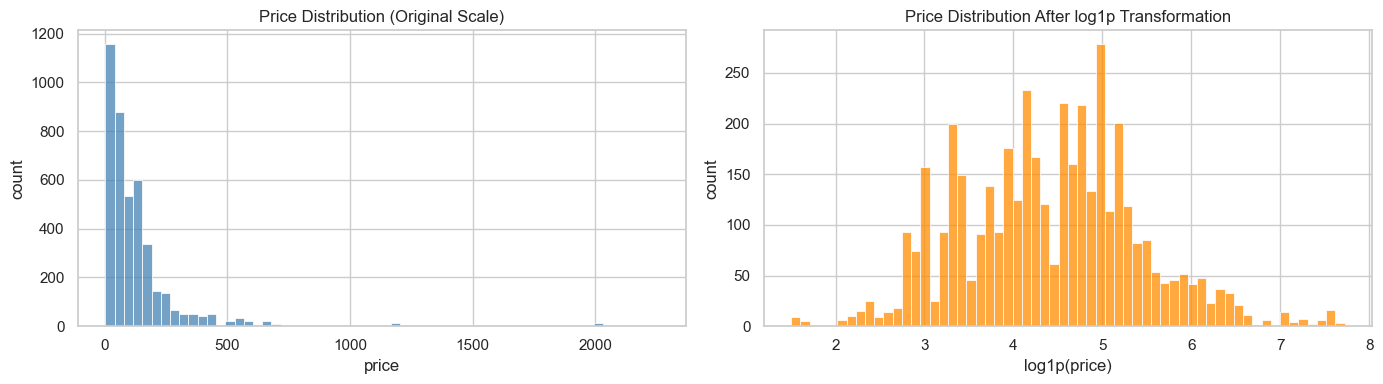

In [ ]:
# 5.1 价格分布（原始尺度 vs log1p）
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(items_auto2['price'], bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Original Scale)') # 汽车相关订单明细：price 分布（原始尺度）
axes[0].set_xlabel('price')
axes[0].set_ylabel('count')
axes[0].ticklabel_format(style='plain', axis='x')

sns.histplot(items_auto2['log_price'], bins=60, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Price Distribution After log1p Transformation') # price 的 log1p 变换后分布（更接近对称）
axes[1].set_xlabel('log1p(price)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

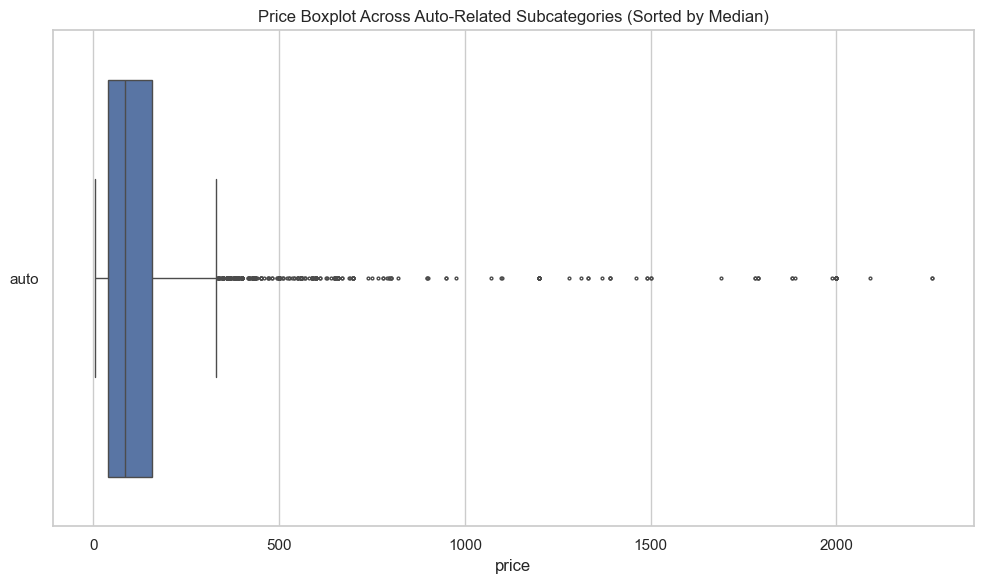

In [ ]:
# 5.2 子类目价格对比（Top 12 类目）
cat_top = items_auto2['category_en'].value_counts().head(12).index.tolist()
plot_df = items_auto2.loc[items_auto2['category_en'].isin(cat_top)].copy()

# 按中位数排序
med = plot_df.groupby('category_en')['price'].median().sort_values(ascending=False)
order = med.index.tolist()

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, y='category_en', x='price', order=order, fliersize=2)
plt.title('Price Boxplot Across Auto-Related Subcategories (Sorted by Median)') # 不同汽车相关子类目：price 箱线图（按中位数排序）'
plt.xlabel('price')
plt.ylabel('')
plt.tight_layout()
plt.show()

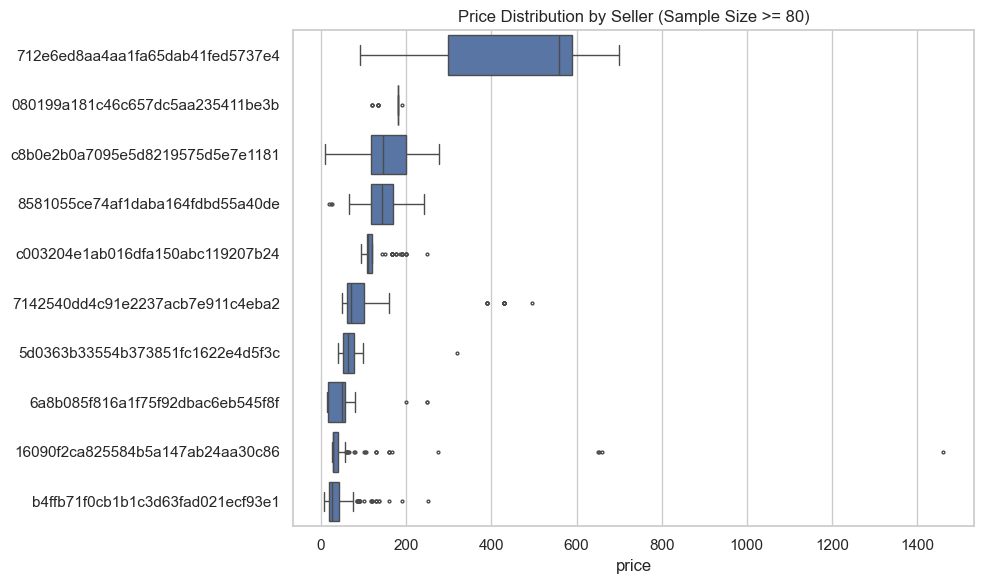

In [ ]:
# 5.3 卖家维度的价格差异（样本量>=80，取前 15 个）
seller_counts = items_auto2['seller_id'].value_counts()
seller_top = seller_counts[seller_counts >= 80].head(15).index.tolist()
plot_df = items_auto2.loc[items_auto2['seller_id'].isin(seller_top)].copy()

med = plot_df.groupby('seller_id')['price'].median().sort_values(ascending=False)
order = med.index.tolist()

plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_df, y='seller_id', x='price', order=order, fliersize=2)
plt.title('Price Distribution by Seller (Sample Size >= 80)') # 卖家（样本量>=80）价格分布对比'
plt.xlabel('price')
plt.ylabel('')
plt.tight_layout()
plt.show()

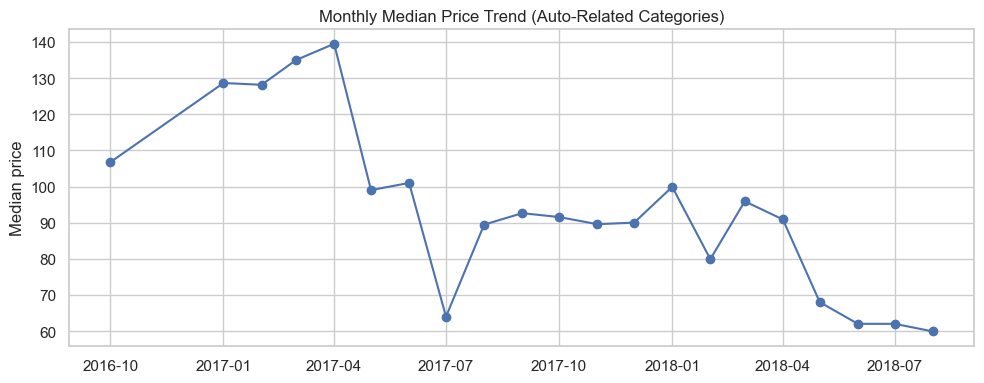

,month,n,median_price,p90_price
16,2018-04-01,356,90.885,273.645
17,2018-05-01,311,68.000,335.900
18,2018-06-01,300,62.000,300.500
19,2018-07-01,344,62.000,243.927
20,2018-08-01,377,59.900,181.600


In [ ]:
# 5.4 时间趋势：月度价格中位数与 P90
trend = (items_auto2
         .dropna(subset=['month'])
         .groupby('month')
         .agg(n=('price','size'),
              median_price=('price','median'),
              p90_price=('price', lambda x: np.quantile(x, 0.9)))
         .reset_index()
        )

plt.figure(figsize=(10,4))
plt.plot(trend['month'], trend['median_price'], marker='o', linewidth=1.5)
plt.title('Monthly Median Price Trend (Auto-Related Categories)') # 月度价格中位数趋势（汽车相关类目）
plt.xlabel('')
plt.ylabel('Median price')
plt.tight_layout()
plt.show()

trend.tail()

## 6. 异常检测（Outlier Detection）

按类目分组，基于 `log_price` 的 IQR 规则标记异常：
- outlier if `log_price > Q3 + 1.5*IQR` 或 `< Q1 - 1.5*IQR`

In [20]:
def mark_iqr_outlier(g, col='log_price'):
    q1 = g[col].quantile(0.25)
    q3 = g[col].quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    g = g.copy()
    g['q1'] = q1
    g['q3'] = q3
    g['iqr'] = iqr
    g['is_outlier'] = (g[col] < lo) | (g[col] > hi)
    return g

outlier_tbl = (items_auto2
               .dropna(subset=['category_en'])
               .groupby('category_en', group_keys=False)
               .apply(mark_iqr_outlier, col='log_price')
              )

outlier_tbl['is_outlier'].value_counts(dropna=False)

is_outlier
False    4188
True       47
Name: count, dtype: int64

In [21]:
outlier_examples = (outlier_tbl
    .loc[outlier_tbl['is_outlier']]
    .sort_values('price', ascending=False)
    [[
        'order_id','order_item_id','seller_id','category_en',
        'price','freight_value','landed_cost','product_weight_g','seller_state','purchase_time'
    ]]
    .head(20)
)
outlier_examples

,order_id,order_item_id,seller_id,category_en,price,freight_value,landed_cost,product_weight_g,seller_state,purchase_time
70957,a1e313e06320d5c725c2ba02d0cf5be2,1,40db9e9aa57f7bb151bcda6b0f9bdbb7,auto,2258.00,64.32,2322.32,4800.0,PE,2018-08-14 20:02:28
79445,b4b1ec9a9f24d8db544120456a3a2f12,1,40db9e9aa57f7bb151bcda6b0f9bdbb7,auto,2258.00,46.68,2304.68,4800.0,PE,2018-07-27 14:28:20
43582,63089c5f142cc1148a1d7799a8359e8a,1,40db9e9aa57f7bb151bcda6b0f9bdbb7,auto,2090.00,61.29,2151.29,3000.0,PE,2018-06-12 19:20:44
110819,fbc8e8d5591dc594ede3b88033625bd0,1,9b1585752613ec342d03bbab9997ec48,auto,1999.99,22.34,2022.33,1800.0,RJ,2018-08-16 23:24:34
66723,987f3d9ad096993454ef3c2c4d9f7a68,1,b1b3948701c5c72445495bd161b83a4c,auto,1999.99,33.49,2033.48,3000.0,SP,2017-06-18 23:14:38
67941,9b4ea4ff8f51f91557fd6448e909cf81,1,b1b3948701c5c72445495bd161b83a4c,auto,1999.99,26.55,2026.54,3000.0,SP,2017-06-18 12:16:28
95758,d9374184c685550085112ae190d8f9c0,1,b1b3948701c5c72445495bd161b83a4c,auto,1999.99,36.87,2036.86,3000.0,SP,2017-06-14 15:29:08
96967,dc03cba6a1d6cf5c28d1fde5dab9a0bd,1,b1b3948701c5c72445495bd161b83a4c,auto,1999.99,34.49,2034.48,3000.0,SP,2017-07-18 09:22:02
99788,e23eaa3bc8275c392145e736dbdea275,1,b1b3948701c5c72445495bd161b83a4c,auto,1999.99,26.55,2026.54,3000.0,SP,2017-06-18 17:22:09
60046,88ce73cc24548143016810f81a9e53d4,1,b1b3948701c5c72445495bd161b83a4c,auto,1999.99,26.55,2026.54,3000.0,SP,2017-07-18 18:49:15


## 7. 建模：解释价格差异（Regression for Price）

思路：
- 目标变量：`log_price`（减少长尾影响）
- 自变量：重量、运费、卖家州、月份（时间控制）

使用 OLS（statsmodels）便于查看系数并做解释。

In [23]:
model_df = (items_auto2
            .dropna(subset=['product_weight_g','freight_value','seller_state','month'])
            .copy()
           )

# 与 R 版一致：用 log1p(weight)、log1p(freight)，并把 seller_state/month 作为分类变量
model_df['log_weight'] = np.log1p(model_df['product_weight_g'])
model_df['log_freight'] = np.log1p(model_df['freight_value'])
model_df['month_str'] = model_df['month'].dt.strftime('%Y-%m')

lm1 = smf.ols('log_price ~ log_weight + log_freight + C(seller_state) + C(month_str)', data=model_df).fit()
lm1.summary().tables[0]

Dep. Variable:,log_price,R-squared:,0.482
Model:,OLS,Adj. R-squared:,0.477
Method:,Least Squares,F-statistic:,108.4
Date:,"Mon, 23 Mar 2026",Prob (F-statistic):,0.00
Time:,15:18:10,Log-Likelihood:,-4613.4
No. Observations:,4235,AIC:,9301.
Df Residuals:,4198,BIC:,9536.
Df Model:,36,,
Covariance Type:,nonrobust,,


In [24]:
# 系数表（按 |t| 排序）
coef_tbl = (pd.DataFrame({
    'term': lm1.params.index,
    'estimate': lm1.params.values,
    'std_error': lm1.bse.values,
    't': lm1.tvalues.values,
    'pvalue': lm1.pvalues.values
})
.assign(abs_t=lambda d: d['t'].abs())
.sort_values('abs_t', ascending=False)
)
coef_tbl.head(25)

,term,estimate,std_error,t,pvalue,abs_t
35,log_weight,0.318012,0.008631,36.846887,9.047529e-258,36.846887
36,log_freight,0.447820,0.026976,16.600537,5.435815e-60,16.600537
6,C(seller_state)[T.PE],2.035323,0.377421,5.392708,7.322052e-08,5.392708
0,Intercept,0.964760,0.394537,2.445294,1.451423e-02,2.445294
12,C(seller_state)[T.RS],-0.664920,0.336150,-1.978048,4.798859e-02,1.978048
2,C(seller_state)[T.ES],-1.041643,0.528437,-1.971179,4.876901e-02,1.971179
20,C(month_str)[T.2017-06],0.365214,0.219797,1.661592,9.666918e-02,1.661592
10,C(seller_state)[T.RN],-0.917891,0.605813,-1.515139,1.298126e-01,1.515139
18,C(month_str)[T.2017-04],0.308652,0.222599,1.386587,1.656414e-01,1.386587
1,C(seller_state)[T.DF],-0.520178,0.404240,-1.286805,1.982332e-01,1.286805


## 8. 预测：随机森林（Random Forest）

目标：预测 `log_price`（即 `log1p(price)`）。

特征：重量、运费、卖家州、月份序号（month_index）。

注：对树模型标准化不是必须，但这里保持与 R 版思路一致（编码 + 标准化数值列）。

In [25]:
rf_df = (items_auto2
         .dropna(subset=['product_weight_g','freight_value','seller_state','month'])
         .copy()
        )

rf_df['month_index'] = rf_df['month'].astype('int64') // 10**9  # seconds since epoch

rf_df = rf_df[['log_price','product_weight_g','freight_value','seller_state','month_index']].copy()

X = rf_df.drop(columns=['log_price'])
y = rf_df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

num_features = ['product_weight_g','freight_value','month_index']
cat_features = ['seller_state']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler())]), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ],
    remainder='drop'
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=123,
    n_jobs=-1,
    min_samples_leaf=5
)

model = Pipeline(steps=[('preprocess', preprocess), ('rf', rf)])
model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['product_weight_g',
                                                   'freight_value',
                                                   'month_index']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['seller_state'])])),
                ('rf',
                 RandomForestRegressor(min_samples_leaf=5, n_estimators=500,
                                       n_jobs=-1, random_state=123))])

In [26]:
model.fit(X_train, y_train)
pred = model.predict(X_test)

rmse = mean_squared_error(y_test, pred, squared=False)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

pd.DataFrame({'metric': ['RMSE','MAE','R2'], 'value': [rmse, mae, r2]})

,metric,value
0,RMSE,0.593433
1,MAE,0.407182
2,R2,0.651533


## 9. 导出清洗后的数据（可选）

In [27]:
out_dir = pathlib.Path('data_processed')
out_dir.mkdir(parents=True, exist_ok=True)

items_auto2.to_csv(out_dir / 'items_auto_clean.csv', index=False)
print('Saved:', out_dir / 'items_auto_clean.csv')

Saved: data_processed/items_auto_clean.csv
